In [24]:
import numpy as np
import folium
from folium.plugins import HeatMap
import pandas as pd
import os
os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")

# Ensure numeric
df = pd.read_csv("output/text/paragraphs_with_best_location.csv")
df["best_lat"] = pd.to_numeric(df["best_lat"], errors="coerce")
df["best_lon"] = pd.to_numeric(df["best_lon"], errors="coerce")

# Drop missing coords
df = df.dropna(subset=["best_lat", "best_lon", "sentiment_stars"])

# Split
pos = df[df["sentiment_stars"] == 2]
neg = df[df["sentiment_stars"] == 1]

# Center map
center = [df["best_lat"].mean(), df["best_lon"].mean()]
m = folium.Map(location=center, zoom_start=4, tiles="CartoDB positron")

# Heatmap data: [lat, lon, weight]
pos_data = pos[["best_lat", "best_lon"]].assign(w=1.0).values.tolist()
neg_data = neg[["best_lat", "best_lon"]].assign(w=1.0).values.tolist()

# Custom gradients (tweak as you like)
pos_gradient = {0.0: "transparent", 0.4: "#a1d99b", 0.7: "#31a354", 1.0: "#006d2c"}
neg_gradient = {0.0: "transparent", 0.4: "#fcae91", 0.7: "#fb6a4a", 1.0: "#cb181d"}

HeatMap(
    pos_data,
    name="Positive sentiment",
    radius=18,
    blur=22,
    max_zoom=6,
    gradient=pos_gradient,
).add_to(m)

HeatMap(
    neg_data,
    name="Negative sentiment",
    radius=18,
    blur=22,
    max_zoom=6,
    gradient=neg_gradient,
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# in Jupyter this renders; otherwise: m.save("sentiment_map.html")

m.save("output/figures/sentiment_analysis/sentiment_map.html")

In [25]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

CSV_PATH = "output/text/paragraphs_with_best_location.csv"
GPKG_PATH = "data/cbsgebiedsindelingen2025.gpkg"
OUT_DIR = "output/figures/sentiment_analysis/"
os.makedirs(OUT_DIR, exist_ok=True)

LAYER_GEMEENTE = "gemeente_gegeneraliseerd"
LAYER_PROVINCIE = "provincie_gegeneraliseerd"

def load_points(csv_path: str) -> gpd.GeoDataFrame:
    df = pd.read_csv(csv_path)
    df["best_lat"] = pd.to_numeric(df["best_lat"], errors="coerce")
    df["best_lon"] = pd.to_numeric(df["best_lon"], errors="coerce")
    df["sentiment_stars"] = pd.to_numeric(df["sentiment_stars"], errors="coerce")
    df = df.dropna(subset=["best_lat", "best_lon", "sentiment_stars"]).copy()

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["best_lon"], df["best_lat"]),
        crs="EPSG:4326",
    )
    return gdf

def guess_name_cols(poly: gpd.GeoDataFrame):
    """Try to find reasonable ID/name columns, fallback to index."""
    cols = set(poly.columns.str.lower())
    # Common CBS-ish fields (varies by layer/export)
    candidates = [
        ("gm_code", "gm_naam"),
        ("prov_code", "prov_naam"),
        ("statcode", "statnaam"),
        ("code", "naam"),
        ("gemeentecode", "gemeentenaam"),
        ("provinciecode", "provincienaam"),
    ]
    for c1, c2 in candidates:
        if c1 in cols and c2 in cols:
            # return original-case names
            real_c1 = poly.columns[[x.lower() == c1 for x in poly.columns]][0]
            real_c2 = poly.columns[[x.lower() == c2 for x in poly.columns]][0]
            return real_c1, real_c2

    # Otherwise: pick something that looks like code/name if present
    name_like = [c for c in poly.columns if str(c).lower() in ("naam", "name", "statnaam", "gemeentenaam", "provincienaam")]
    code_like = [c for c in poly.columns if "code" in str(c).lower() or "stat" in str(c).lower()]
    code_col = code_like[0] if code_like else None
    name_col = name_like[0] if name_like else None
    return code_col, name_col

def aggregate_by_region(points_wgs84: gpd.GeoDataFrame, gpkg_path: str, layer: str, region_label: str):
    poly = gpd.read_file(gpkg_path, layer=layer)

    # Make CRS match for spatial join
    if poly.crs is None:
        raise ValueError(f"Polygon layer '{layer}' has no CRS. Please set poly.set_crs(...) appropriately.")
    pts = points_wgs84.to_crs(poly.crs)

    # Spatial join: assign each point to a region polygon
    joined = gpd.sjoin(pts, poly, predicate="within", how="inner")

    if joined.empty:
        raise ValueError(f"No points fell within polygons for layer '{layer}'. Check CRS and coordinates.")

    code_col, name_col = guess_name_cols(poly)

    # Use a stable join key for aggregation (prefer code, else name, else index_right)
    if code_col:
        key = code_col
    elif name_col:
        key = name_col
    else:
        key = "index_right"  # from sjoin

    # Counts
    joined["is_pos"] = (joined["sentiment_stars"] == 2).astype(int)
    joined["is_neg"] = (joined["sentiment_stars"] == 1).astype(int)

    agg = (
        joined.groupby(key, as_index=False)
              .agg(
                  n_total=("sentiment_stars", "size"),
                  n_pos=("is_pos", "sum"),
                  n_neg=("is_neg", "sum"),
              )
    )
    agg["pct_pos"] = 100.0 * agg["n_pos"] / agg["n_total"]
    agg["pct_neg"] = 100.0 * agg["n_neg"] / agg["n_total"]

    # Attach aggregated values back to polygons for mapping
    poly_map = poly.copy()
    poly_map = poly_map.merge(agg, on=key, how="left")

    # Optional: label column for nice titles/tooltips
    if name_col and "region_name" not in poly_map.columns:
        poly_map["region_name"] = poly_map[name_col].astype(str)
    else:
        poly_map["region_name"] = poly_map[key].astype(str)

    # Save a CSV summary for inspection
    agg_out = os.path.join(OUT_DIR, f"{region_label}_sentiment_summary.csv")
    agg.sort_values("n_total", ascending=False).to_csv(agg_out, index=False)

    return poly_map, agg_out

def plot_choropleth(poly_map: gpd.GeoDataFrame, value_col: str, title: str, out_path: str):
    fig, ax = plt.subplots(figsize=(9, 11), dpi=200)

    # Plot with a clear missing-data style
    poly_map.plot(
        column=value_col,
        ax=ax,
        legend=True,
        cmap="viridis",
        missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"},
        linewidth=0.2,
        edgecolor="white",
    )

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)

points = load_points(CSV_PATH)

# --- Gemeenten ---
gemeente_map, gemeente_csv = aggregate_by_region(points, GPKG_PATH, LAYER_GEMEENTE, "gemeente")
plot_choropleth(
    gemeente_map, "pct_pos",
    "Gemeenten — % positive sentiment",
    os.path.join(OUT_DIR, "gemeenten_pct_positive.png")
)
plot_choropleth(
    gemeente_map, "pct_neg",
    "Gemeenten — % negative sentiment",
    os.path.join(OUT_DIR, "gemeenten_pct_negative.png")
)

# --- Provincies ---
prov_map, prov_csv = aggregate_by_region(points, GPKG_PATH, LAYER_PROVINCIE, "provincie")
plot_choropleth(
    prov_map, "pct_pos",
    "Provincies — % positive sentiment",
    os.path.join(OUT_DIR, "provincies_pct_positive.png")
)
plot_choropleth(
    prov_map, "pct_neg",
    "Provincies — % negative sentiment",
    os.path.join(OUT_DIR, "provincies_pct_negative.png")
)

print("Saved figures to:", OUT_DIR)
print("Saved summaries:", gemeente_csv, "and", prov_csv)


Saved figures to: output/figures/sentiment_analysis/
Saved summaries: output/figures/sentiment_analysis/gemeente_sentiment_summary.csv and output/figures/sentiment_analysis/provincie_sentiment_summary.csv


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
from folium.features import GeoJsonTooltip
import branca.colormap as cm

CSV_PATH = "output/text/paragraphs_with_best_location.csv"
GPKG_PATH = "data/cbsgebiedsindelingen2025.gpkg"
OUT_DIR = "output/sentiment_analysis/figures"
os.makedirs(OUT_DIR, exist_ok=True)

LAYER_GEMEENTE = "gemeente_gegeneraliseerd"
LAYER_PROVINCIE = "provincie_gegeneraliseerd"

MIN_N_PROV = 10  # <-- filter provinces with fewer points than this


def load_points(csv_path: str) -> gpd.GeoDataFrame:
    df = pd.read_csv(csv_path)
    df["best_lat"] = pd.to_numeric(df["best_lat"], errors="coerce")
    df["best_lon"] = pd.to_numeric(df["best_lon"], errors="coerce")
    df["sentiment_stars"] = pd.to_numeric(df["sentiment_stars"], errors="coerce")
    df = df.dropna(subset=["best_lat", "best_lon", "sentiment_stars"]).copy()

    return gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["best_lon"], df["best_lat"]),
        crs="EPSG:4326",
    )


def guess_name_cols(poly: gpd.GeoDataFrame):
    cols_lower = [c.lower() for c in poly.columns]

    def find(colname):
        if colname in cols_lower:
            return poly.columns[cols_lower.index(colname)]
        return None

    # Common CBS-ish fields (varies by export)
    code_col = find("statcode") or find("gm_code") or find("prov_code") or find("code")
    name_col = find("statnaam") or find("gm_naam") or find("prov_naam") or find("naam") or find("name")
    return code_col, name_col


def aggregate(points_wgs84: gpd.GeoDataFrame, gpkg_path: str, layer: str) -> gpd.GeoDataFrame:
    poly = gpd.read_file(gpkg_path, layer=layer)

    if poly.crs is None:
        raise ValueError(f"Polygon layer '{layer}' has no CRS. Please set it before joining.")

    pts = points_wgs84.to_crs(poly.crs)

    # Spatial join: assign each point to a region polygon
    joined = gpd.sjoin(pts, poly, predicate="within", how="inner").drop(columns=["index_right"])
    if joined.empty:
        raise ValueError(f"No points fell within polygons for layer '{layer}'. Check CRS/coordinates.")

    code_col, name_col = guess_name_cols(poly)
    key = code_col or name_col
    if key is None:
        raise ValueError(
            f"Could not find a suitable code/name column in layer '{layer}'. "
            f"Available columns: {list(poly.columns)}"
        )

    joined["is_pos"] = (joined["sentiment_stars"] == 2).astype(int)
    joined["is_neg"] = (joined["sentiment_stars"] == 1).astype(int)

    agg = (
        joined.groupby(key, as_index=False)
        .agg(
            n_total=("sentiment_stars", "size"),
            n_pos=("is_pos", "sum"),
            n_neg=("is_neg", "sum"),
        )
    )
    agg["pct_pos"] = 100.0 * agg["n_pos"] / agg["n_total"]
    agg["pct_neg"] = 100.0 * agg["n_neg"] / agg["n_total"]

    out = poly.merge(agg, on=key, how="left")

    # nice labels for tooltip
    out["region_code"] = out[key].astype(str)
    if name_col is not None:
        out["region_name"] = out[name_col].astype(str)
    else:
        out["region_name"] = out["region_code"]

    return out


def make_interactive_choropleth(poly_map: gpd.GeoDataFrame, out_html: str, title: str):
    # Folium expects WGS84
    g = poly_map.to_crs("EPSG:4326").copy()

    # Ensure columns exist
    for c in ["n_total", "n_pos", "n_neg", "pct_pos", "pct_neg"]:
        if c not in g.columns:
            g[c] = np.nan

    # Compute adaptive vmin/vmax from available pct_pos values
    vals = g["pct_pos"].dropna()
    if vals.empty:
        raise ValueError(f"No pct_pos values available for map '{title}'.")
    vmin = float(vals.min())
    vmax = float(vals.max())
    if np.isclose(vmin, vmax):
        # prevent zero-range colormap
        vmin = max(0.0, vmin - 1.0)
        vmax = min(100.0, vmax + 1.0)

    # High-contrast sequential palette, but now stretched to your min..max
    col = cm.LinearColormap(
        ["#bd0026", "#f03b20", "#fd8d3c", "#fecc5c", "#ffffb2"],
        vmin=vmin,
        vmax=vmax,
    )

    col.caption = f"% positive (range: {vmin:.1f}–{vmax:.1f})"

    bounds = g.total_bounds  # (minx, miny, maxx, maxy)
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

    m = folium.Map(location=center, zoom_start=7, tiles="CartoDB positron", control_scale=True)
    m.get_root().html.add_child(folium.Element(f"<h3 style='margin:10px'>{title}</h3>"))

    col.add_to(m)

    tooltip = GeoJsonTooltip(
        fields=["region_name", "region_code", "n_total", "n_pos", "n_neg", "pct_pos", "pct_neg"],
        aliases=["Region", "Code", "Total", "Positive", "Negative", "% positive", "% negative"],
        localize=True,
        sticky=False,
        labels=True,
        style=(
            "background-color: white; color: #333; font-family: Arial; font-size: 12px; "
            "padding: 8px; border: 1px solid #999; border-radius: 4px;"
        ),
    )

    def style_function(feat):
        v = feat["properties"].get("pct_pos", None)
        if v is None:
            return {"fillColor": "#d9d9d9", "color": "white", "weight": 0.6, "fillOpacity": 0.5}
        try:
            if np.isnan(v):
                return {"fillColor": "#d9d9d9", "color": "white", "weight": 0.6, "fillOpacity": 0.5}
        except Exception:
            pass
        return {"fillColor": col(v), "color": "white", "weight": 0.6, "fillOpacity": 0.8}

    def highlight_function(_):
        return {"weight": 2.0, "color": "#000000"}

    folium.GeoJson(
        g,
        name="Choropleth (% positive)",
        style_function=style_function,
        highlight_function=highlight_function,
        tooltip=tooltip,
    ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])
    m.save(out_html)
    print("Saved:", out_html)


# ---- Run ----
points = load_points(CSV_PATH)

# Gemeenten map (no filtering requested)
gemeenten = aggregate(points, GPKG_PATH, LAYER_GEMEENTE)
make_interactive_choropleth(
    gemeenten,
    os.path.join(OUT_DIR, "gemeenten_sentiment_interactive.html"),
    "Gemeenten — sentiment (% positive), hover for counts",
)

# Provincies map (filter out low-n provinces, then adaptive scale)
provincies = aggregate(points, GPKG_PATH, LAYER_PROVINCIE)
provincies = provincies[provincies["n_total"].fillna(0) >= MIN_N_PROV].copy()

make_interactive_choropleth(
    provincies,
    os.path.join(OUT_DIR, "provincies_sentiment_interactive.html"),
    f"Provincies — sentiment (% positive), n ≥ {MIN_N_PROV}, hover for counts",
)


Saved: output/figures/gemeenten_sentiment_interactive.html
Saved: output/figures/provincies_sentiment_interactive.html


In [10]:
import pandas as pd
import os

os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")

sentiment_paragraphs = pd.read_csv("output/text/paragraph_sentiment_with_metadata.csv")

In [11]:
sentiment_paragraphs['word_count'] = sentiment_paragraphs['paragraph_text'].apply(lambda x: len(str(x).split()))

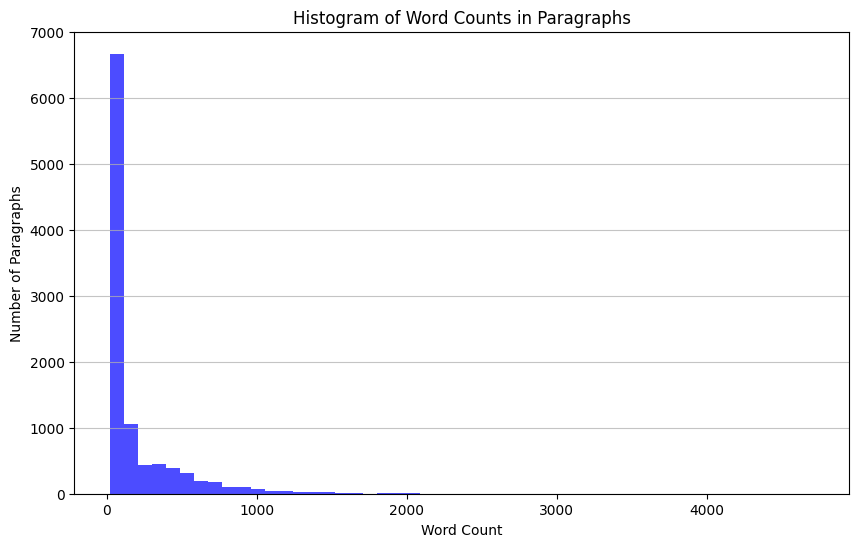

In [12]:
#create a histogram of word counts
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.hist(sentiment_paragraphs['word_count'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Word Counts in Paragraphs')
plt.xlabel('Word Count')
plt.ylabel('Number of Paragraphs')
plt.grid(axis='y', alpha=0.75)
plt.savefig("output/figures/sentiment_analysis/paragraph_word_count_histogram.png")
plt.show()

8242 paragraphs after filtering for word count between 30 and 500.


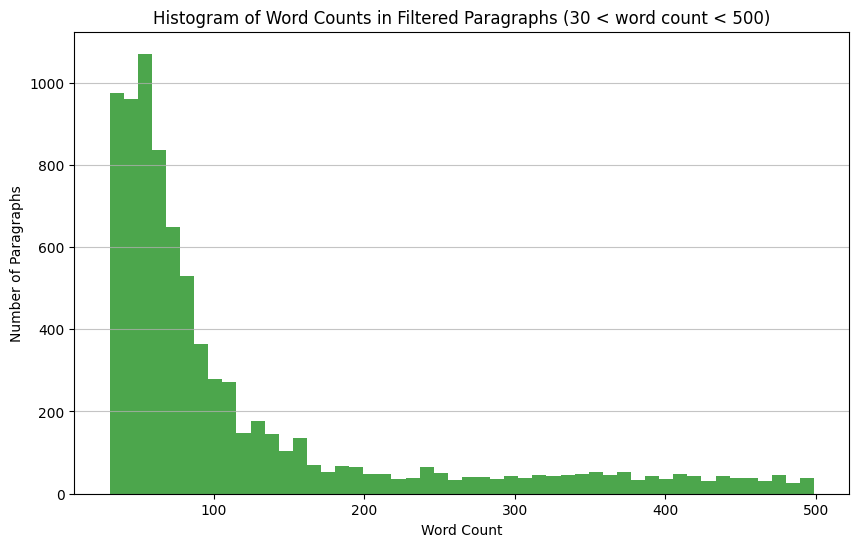

In [13]:
# filter paragraphs with word count > 30 and <500
filtered_paragraphs = sentiment_paragraphs[(sentiment_paragraphs['word_count'] > 30) & (sentiment_paragraphs['word_count'] < 500)]
print(len(filtered_paragraphs), "paragraphs after filtering for word count between 30 and 500.")
#create a new histogram of filtered word counts
plt.figure(figsize=(10,6))
plt.hist(filtered_paragraphs['word_count'], bins=50, color='green', alpha=0.7)
plt.title('Histogram of Word Counts in Filtered Paragraphs (30 < word count < 500)')
plt.xlabel('Word Count')
plt.ylabel('Number of Paragraphs')
plt.grid(axis='y', alpha=0.75)
plt.savefig("output/figures/sentiment_analysis/paragraph_word_count_histogram.png")
plt.show()

In [9]:
print(filtered_paragraphs.head())

             source_file                                        source_path  \
0  Bestanden (1-500).RTF  /Users/Yannick/Documents/PhD/text_mining/geoth...   
1  Bestanden (1-500).RTF  /Users/Yannick/Documents/PhD/text_mining/geoth...   
2  Bestanden (1-500).RTF  /Users/Yannick/Documents/PhD/text_mining/geoth...   
4  Bestanden (1-500).RTF  /Users/Yannick/Documents/PhD/text_mining/geoth...   
6  Bestanden (1-500).RTF  /Users/Yannick/Documents/PhD/text_mining/geoth...   

                                               title              newspaper  \
0                               'Warmtepomp' rukt op       AD/De Dordtenaar   
1                         Aarde verwarmt Haagse wijk    AD/Haagsche Courant   
2  Tomaten groeien dankzij aardwarmte van zestig ...  AD/Rotterdams Dagblad   
4  Warmte- bedrijf is niet haalbaar - Nieuwe wijk...    AD/Haagsche Courant   
6  1,4 miljoen in mislukt warmtebedrijf - Voor zo...    AD/Haagsche Courant   

               date section  word_count          l